In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from moabb.datasets import Gao2026, BNCI2014_001
from moabb.paradigms import MotorImagery
from torch_geometric.utils import from_scipy_sparse_matrix
from scipy.sparse import csr_matrix
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Initialize the dataset
dataset = Gao2026()

# 2. Get data for a specific subject (returns a dict: {session: {run: raw_mne}})
data = dataset.get_data(subjects=[1])

# 3. Access the first available Raw object
# Structure: data[subject_id][session_id][run_id]
first_session = list(data[1].keys())[0]
first_run = list(data[1][first_session].keys())[0]
raw_obj = data[1][first_session][first_run]

# 4. Extract the Montage (Physical Positions)
montage = raw_obj.get_montage()

# 5. Get the positions as a dictionary {ch_name: [x, y, z]}
positions = montage.get_positions()['ch_pos']

for ch, pos in positions.items():
    print(f"Electrode {ch}: {pos}")

Electrode Fpz: [-0.00133733  0.1191018   0.0328899 ]
Electrode Fp1: [-0.03090259  0.11458518  0.02786657]
Electrode Fp2: [0.0284095  0.11534631 0.02772126]
Electrode Fz: [-0.00122927  0.09327445  0.10263929]
Electrode F3: [-0.05180904  0.0866879   0.07871409]
Electrode F4: [0.05027428 0.08743839 0.07727065]
Electrode F7: [-0.07187663  0.07310353  0.02579046]
Electrode F8: [0.07143527 0.07450513 0.02510103]
Electrode FCz: [-0.00127143  0.06345979  0.12657198]
Electrode FC3: [-0.06185234  0.05713329  0.09376583]
Electrode FC4: [0.06062548 0.05770742 0.09379462]
Electrode FT7: [-0.08248931  0.04484874  0.02768058]
Electrode FT8: [0.08010433 0.04555358 0.02741239]
Electrode Cz: [-0.00137413  0.02761709  0.14019949]
Electrode C3: [-0.06714872  0.02335823  0.10451068]
Electrode C4: [0.06532888 0.0235731  0.10369243]
Electrode T7: [-0.08598208  0.01487164  0.03117337]
Electrode T8: [0.08326137 0.01525819 0.03097297]
Electrode CP3: [-0.06547223 -0.0118966   0.10777792]
Electrode CP4: [ 0.06469

In [2]:
# 1. Initialize the dataset
dataset = BNCI2014_001()

# 2. Get data for a specific subject (returns a dict: {session: {run: raw_mne}})
data = dataset.get_data(subjects=[1])

# 3. Access the first available Raw object
# Structure: data[subject_id][session_id][run_id]
first_session = list(data[1].keys())[0]
first_run = list(data[1][first_session].keys())[0]
raw_obj = data[1][first_session][first_run]

# 4. Extract the Montage (Physical Positions)
montage = raw_obj.get_montage()

# 5. Get the positions as a dictionary {ch_name: [x, y, z]}
positions = montage.get_positions()['ch_pos']

for ch, pos in positions.items():
    print(f"Electrode {ch}: {pos}")

Electrode Fz: [-0.00122927  0.09327445  0.10263929]
Electrode FC3: [-0.06185234  0.05713329  0.09376583]
Electrode FC1: [-0.03571586  0.06171406  0.11798302]
Electrode FCz: [-0.00127143  0.06345979  0.12657198]
Electrode FC2: [0.03313098 0.06182849 0.1167817 ]
Electrode FC4: [0.06062548 0.05770742 0.09379462]
Electrode C5: [-0.0820853   0.01929363  0.06948967]
Electrode C3: [-0.06714872  0.02335823  0.10451068]
Electrode C1: [-0.03793782  0.02633745  0.12977061]
Electrode Cz: [-0.00137413  0.02761709  0.14019949]
Electrode C2: [0.03589272 0.02635814 0.12841234]
Electrode C4: [0.06532888 0.0235731  0.10369243]
Electrode C6: [0.08165317 0.01969566 0.06948181]
Electrode CP3: [-0.06547223 -0.0118966   0.10777792]
Electrode CP1: [-0.03742513 -0.01082424  0.13344371]
Electrode CPz: [-0.0015249  -0.01051838  0.14154914]
Electrode CP2: [ 0.03647196 -0.01090379  0.13281227]
Electrode CP4: [ 0.06469626 -0.01199118  0.10771287]
Electrode P1: [-0.03065362 -0.04492739  0.11947205]
Electrode Pz: [-0

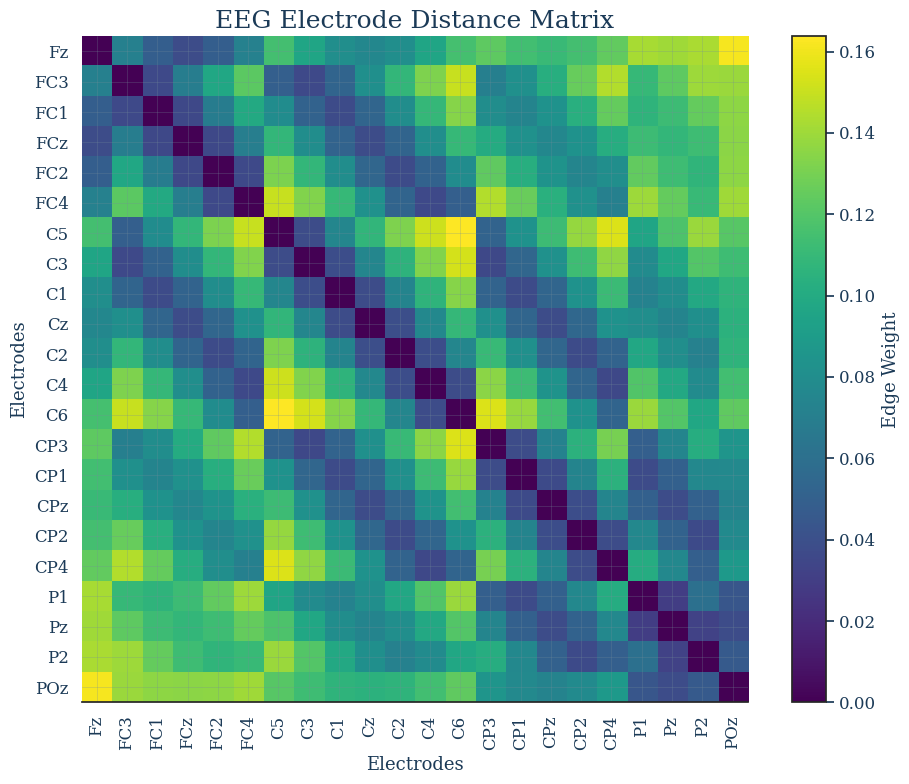

In [3]:
labels = list(positions.keys())

coordinates = np.array(list(positions.values()))
distance_matrix = np.zeros((len(positions), len(positions)))

for row in range(coordinates.shape[0]):
    for column in range(coordinates.shape[0]):

        displacement = coordinates[row] - coordinates[column]
        distance = np.sqrt(np.dot(displacement, displacement))
        distance_matrix[row, column] = distance


def visualize_matrix(matrix, title: str = ""):
    # Colored visualization of the adjacency (distance) matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    heatmap = ax.imshow(matrix, cmap="viridis", interpolation="nearest")

    # Add colorbar to show distance scale
    cbar = plt.colorbar(heatmap, ax=ax)
    cbar.set_label("Edge Weight")

    # Add channel labels to both axes
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)

    ax.set_title(f"EEG Electrode {title} Matrix")
    ax.set_xlabel("Electrodes")
    ax.set_ylabel("Electrodes")
    plt.tight_layout()
    plt.show()


visualize_matrix(distance_matrix, title="Distance")

/tmp/ipykernel_126151/1751712412.py:14: RuntimeWarning: divide by zero encountered in divide
  adjacency_matrix = np.where(adjacency_matrix > 0, 1/adjacency_matrix, 0)


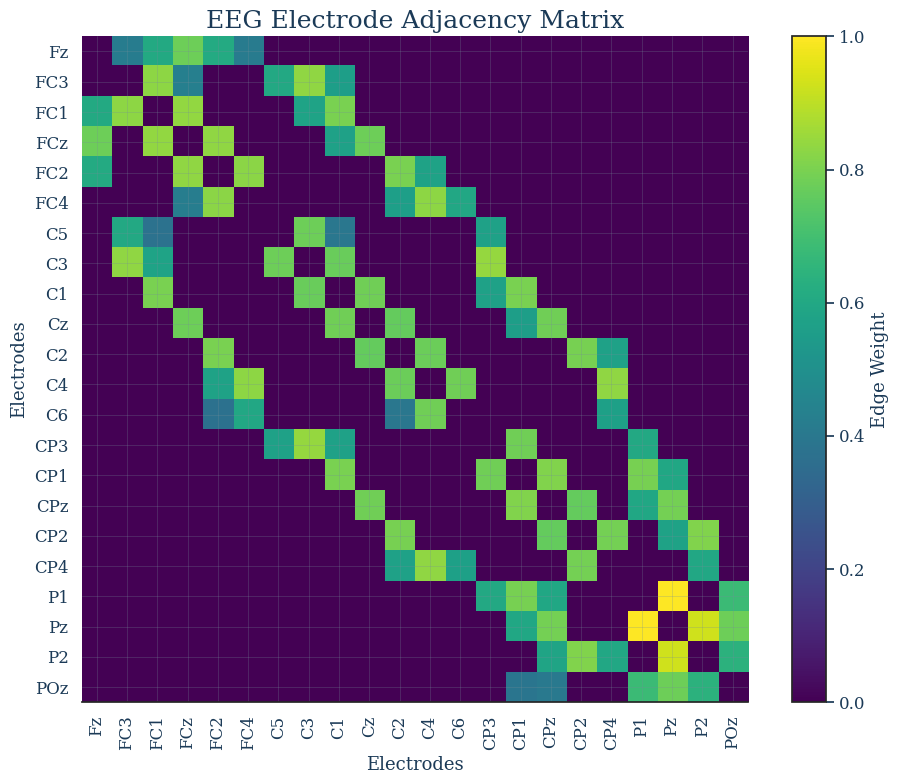

In [23]:
n_closest_neighbours = 5

adjacency_matrix_indices = np.argsort(
    distance_matrix)[:, 1:n_closest_neighbours + 1]

n_channels = distance_matrix.shape[0]
adjacency_matrix_mask = np.zeros((n_channels, n_channels), dtype=int)

# Set 1 for row-wise neighbor matches, 0 otherwise
for row in range(n_channels):
    adjacency_matrix_mask[row, adjacency_matrix_indices[row]] = 1

adjacency_matrix = distance_matrix * adjacency_matrix_mask
adjacency_matrix = np.where(adjacency_matrix > 0, 1/adjacency_matrix, 0)
adjacency_matrix /= np.max(adjacency_matrix)
visualize_matrix(adjacency_matrix, title="Adjacency")

In [24]:
# Convert your numpy adjacency matrix to COO format for PyTorch Geometric
sparse_adj = csr_matrix(adjacency_matrix)
edge_index, edge_weight = from_scipy_sparse_matrix(sparse_adj)

# Ensure they are tensors and move to device later
edge_index = edge_index.to(torch.long)
edge_weight = edge_weight.to(torch.float)

In [ ]:
def get_dataset_loaders(
    dataset,
    sample_frequency=250,
    test_subject_id=1,
    n_subjects=2,
    batch_size=32,
    split_mode="loso",
    test_size=0.2,
    random_state=42
) -> tuple:
    """
    Build train/test loaders for a dataset with two split modes.

    split_mode options:
    - "loso": leave one subject out for testing (test_subject_id).
    - "random": pool all subjects, shuffle, then split by test_size.
    """
    if split_mode not in {"loso", "random"}:
        raise ValueError("split_mode must be either 'loso' or 'random'")

    if not (0 < test_size < 1):
        raise ValueError("test_size must be in the interval (0, 1)")

    max_subjects = dataset.metadata.participants.n_subjects

    if n_subjects == -1:
        n_subjects = max_subjects

    if n_subjects > max_subjects:
        raise ValueError(
            f"{n_subjects} is more subjects than the avaiable {max_subjects}"
        )

    n_classes = dataset.metadata.experiment.n_classes
    paradigm = MotorImagery(n_classes=n_classes, fmin=4,
                            fmax=38, resample=sample_frequency)

    subjects = list(range(1, n_subjects + 1))
    X, y, metadata = paradigm.get_data(
        dataset=dataset, subjects=subjects)  # type: ignore

    if split_mode == "loso":
        if test_subject_id not in subjects:
            raise ValueError(
                f"test_subject_id={test_subject_id} is not in selected subjects: {subjects}")

        subject_ids = metadata["subject"].to_numpy()
        test_mask = subject_ids == test_subject_id
        train_mask = ~test_mask

        if not np.any(test_mask):
            raise RuntimeError(
                f"No test trials found for subject {test_subject_id}. Check subject selection.")
        if not np.any(train_mask):
            raise RuntimeError("No training trials found after LOSO split.")

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

    else:
        # Pool all users, shuffle once, and split by ratio.
        indices = np.arange(len(y))
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

        n_test = int(len(indices) * test_size)
        n_test = min(max(n_test, 1), len(indices) - 1)

        test_indices = indices[:n_test]
        train_indices = indices[n_test:]

        X_train, y_train = X[train_indices], y[train_indices]
        X_test, y_test = X[test_indices], y[test_indices]

    # Preprocessing: add EEGNet channel dimension -> (Batch, 1, Channels, Time)
    X_train = X_train[:, np.newaxis, :, :].astype(np.float32)
    X_test = X_test[:, np.newaxis, :, :].astype(np.float32)

    # Consistent label encoding
    unique_labels = np.unique(y)
    label_dict = {label: i for i, label in enumerate(unique_labels)}
    y_train = np.array([label_dict[l] for l in y_train])
    y_test = np.array([label_dict[l] for l in y_test])

    train_ds = TensorDataset(torch.from_numpy(
        X_train), torch.from_numpy(y_train).long())
    test_ds = TensorDataset(torch.from_numpy(
        X_test), torch.from_numpy(y_test).long())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    if split_mode == "loso":
        print(f"Split Mode: LOSO | Test Subject: {test_subject_id}")
        print(
            f"Training on {len(X_train)} trials from {len(subjects) - 1} subjects")
        print(f"Testing on {len(X_test)} trials from 1 subject")
    else:
        print(
            f"Split Mode: RANDOM | Users pooled | test_size={test_size} | random_state={random_state}")
        print(f"Training on {len(X_train)} trials from all selected subjects")
        print(f"Testing on {len(X_test)} trials from all selected subjects")

    return train_loader, test_loader, n_classes

In [19]:
dataset = BNCI2014_001()
train_loader, test_loader, N_CLASSES = get_dataset_loaders(
    dataset=dataset, n_subjects=-1, sample_frequency=125)

Choosing from all possible events


Split Mode: LOSO | Test Subject: 1
Training on 4608 trials from 8 subjects
Testing on 576 trials from 1 subject


In [20]:
sample_data, sample_label = next(iter(train_loader))
batch_size = sample_data.shape[0]
electrode_channels = sample_data.shape[2]
sample_length = sample_data.shape[3]

print(f"Input Shape for Model: {sample_data.shape}")
print(f"Label Shape: {sample_label.shape}")
print(
    f"Batch size: {batch_size} | Nº Channels: {electrode_channels} | Sample length: {sample_length}")

Input Shape for Model: torch.Size([32, 1, 22, 500])
Label Shape: torch.Size([32])
Batch size: 32 | Nº Channels: 22 | Sample length: 500


In [25]:
from torch_geometric.nn import ChebConv  # Or GCNConv


class STGCN(nn.Module):
    def __init__(
        self,
        kernel_length: int,
        electrode_channels: int,
        temporal_filters: int,
        node_feature_length: int,
        n_classes: int,
        dropout_rate: float = 0.5
    ) -> None:
        super().__init__()

        self.n_channels = electrode_channels
        self.n_filters = temporal_filters
        self.node_features = node_feature_length

        # 1. Temporal Feature Extractor (CNN)
        self.temporal_extractor = nn.Sequential(
            nn.Conv2d(1, temporal_filters, (1, kernel_length),
                      padding="same", bias=False),
            nn.BatchNorm2d(temporal_filters),
            nn.ELU(),
            nn.Dropout(dropout_rate),
            # Output: (Batch, Filters, Channels, Time) -> Pool to (Batch, Filters, Channels, Node_Features)
            nn.AdaptiveAvgPool2d((electrode_channels, node_feature_length))
        )

        # 2. Spatial Feature Extractor (GNN)
        # Input to GNN will be (Batch * Filters, Channels, Node_Features)
        self.gnn = ChebConv(node_feature_length, node_feature_length // 2, K=2)

        # 3. Classifier
        # The flattened size is: Channels * (Node_Features // 2) * Filters
        self.flattened_size = self.n_channels * \
            (node_feature_length // 2) * self.n_filters

        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 64),
            nn.ELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, n_classes)
        )

    def forward(self, x, edge_index, edge_weight):
        # x: (Batch, 1, Channels, Time)
        batch_size = x.size(0)

        # Step 1: CNN Temporal Extraction
        x = self.temporal_extractor(x)  # (B, F, C, N_Feats)

        # Step 2: Prepare for GNN
        # GNN expects (Total_Nodes, Features). We treat B*F as the batch dimension.
        # (B*F, C, N_Feats)
        x = x.view(-1, self.n_channels, self.node_features)

        # Step 3: GNN Spatial Aggregation
        # We broadcast the same edge_index across the meta-batch
        x = self.gnn(x, edge_index, edge_weight)  # (B*F, C, N_Feats // 2)

        # Step 4: Flatten for Classifier
        # Reshape back to (Batch, Filters, Channels, New_Feats) then flatten
        x = x.view(batch_size, self.n_filters, self.n_channels, -1)
        x = x.reshape(batch_size, -1)  # (Batch, Flattened_Size)

        return self.classifier(x)


model = STGCN(
    kernel_length=64,
    electrode_channels=electrode_channels,
    temporal_filters=8,
    node_feature_length=32,
    n_classes=N_CLASSES
)

model.forward(sample_data, edge_index, edge_weight).shape

torch.Size([32, 4])

In [26]:
def train_model(model, train_loader, test_loader, epochs=500, lr=0.001, wd=0.01):
    # 1. Setup Device (GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Keep graph structure tensors on the same device as the model
    edge_index_device = edge_index.to(device)
    edge_weight_device = edge_weight.to(device)

    # 2. Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    print(f"Starting training on {device}...")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for batch_data, batch_labels in train_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward + Backward + Optimize
            outputs = model(batch_data, edge_index_device, edge_weight_device)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # 3. Evaluation and Reporting every 50 epochs
        if epoch % 50 == 0 or epoch == 1:
            model.eval()
            correct = 0
            total = 0
            test_loss = 0.0

            with torch.no_grad():
                for data, labels in test_loader:
                    data = data.to(device)
                    labels = labels.to(device)
                    outputs = model(data, edge_index_device,
                                    edge_weight_device)

                    loss = criterion(outputs, labels)
                    test_loss += loss.item()

                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            avg_test_loss = test_loss / len(test_loader)
            accuracy = 100 * correct / total

            print(f"Epoch [{epoch}/{epochs}] "
                  f"| Train Loss: {running_loss/len(train_loader):.4f} "
                  f"| Test Loss: {avg_test_loss:.4f} "
                  f"| Test Acc: {accuracy:.2f}%")

    print("Training Complete.")


train_model(model, train_loader, test_loader, epochs=10000)

Starting training on cuda...
Epoch [1/10000] | Train Loss: 1.3980 | Test Loss: 1.3462 | Test Acc: 32.99%
Epoch [50/10000] | Train Loss: 1.1169 | Test Loss: 1.2187 | Test Acc: 45.31%
Epoch [100/10000] | Train Loss: 1.1057 | Test Loss: 1.1965 | Test Acc: 46.88%
Epoch [150/10000] | Train Loss: 1.0865 | Test Loss: 1.1757 | Test Acc: 46.01%
Epoch [200/10000] | Train Loss: 1.0762 | Test Loss: 1.1933 | Test Acc: 44.62%
Epoch [250/10000] | Train Loss: 1.0800 | Test Loss: 1.1858 | Test Acc: 47.05%
Epoch [300/10000] | Train Loss: 1.0834 | Test Loss: 1.1706 | Test Acc: 48.96%
Epoch [350/10000] | Train Loss: 1.0895 | Test Loss: 1.1826 | Test Acc: 45.31%
Epoch [400/10000] | Train Loss: 1.0852 | Test Loss: 1.1602 | Test Acc: 48.09%
Epoch [450/10000] | Train Loss: 1.0805 | Test Loss: 1.1700 | Test Acc: 45.31%
Epoch [500/10000] | Train Loss: 1.0732 | Test Loss: 1.1690 | Test Acc: 46.70%
Epoch [550/10000] | Train Loss: 1.0859 | Test Loss: 1.1708 | Test Acc: 48.44%
Epoch [600/10000] | Train Loss: 1.0816

KeyboardInterrupt: 